In [1]:
# ═══════════════════════════════════════════════════
# CELL 1 — Installs
# ═══════════════════════════════════════════════════
!pip install -q semantic-kernel google-genai datasets scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.0/924.0 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.9/217.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.2/115.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.1/192.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.6/106.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# ═══════════════════════════════════════════════════
# CELL 2 — Imports + API setup
# ═══════════════════════════════════════════════════
import re, time, csv, getpass
import numpy as np
from collections import defaultdict
from google import genai
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from semantic_kernel import Kernel
from semantic_kernel.functions import kernel_function, KernelArguments

API_KEY = getpass.getpass("Enter Gemini API key: ")
client  = genai.Client(api_key=API_KEY)

Enter Gemini API key: ··········


In [3]:
# ═══════════════════════════════════════════════════
# CELL 3 — Gemini call with retry backoff
# ═══════════════════════════════════════════════════
def ask_gemini(prompt: str, retries: int = 3, wait: float = 5.0) -> str:
    for attempt in range(retries):
        try:
            response = client.models.generate_content(
                model="gemini-2.5-flash", contents=prompt
            )
            return response.text.strip()
        except Exception as e:
            print(f"  [API error attempt {attempt+1}/{retries}]: {e}")
            if attempt < retries - 1:
                time.sleep(wait * (attempt + 1))
    return ""


In [4]:
# ═══════════════════════════════════════════════════
# CELL 3.5 — Solution RAG: TF-IDF over BoolQ train
# ═══════════════════════════════════════════════════
print("Building solution RAG index from BoolQ train split...")
train_ds = load_dataset("boolq", split="train")

def format_boolq_sample(s):
    q = f"Passage: {s['passage']}\nQuestion: {s['question']}"
    a = "yes" if s["answer"] else "no"
    return q, f"Answer: {a}"

train_questions = [format_boolq_sample(s)[0] for s in train_ds]
train_answers   = [format_boolq_sample(s)[1] for s in train_ds]

vectorizer   = TfidfVectorizer(max_features=50000)  # cap for memory
tfidf_matrix = vectorizer.fit_transform(train_questions)
print(f"Solution RAG ready: {len(train_questions)} examples indexed.")

def retrieve_examples(query: str, top_k: int = 3) -> str:
    q_vec   = vectorizer.transform([query])
    sims    = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_idx = np.argsort(sims)[::-1][:top_k]
    return "\n\n---\n\n".join(
        f"Example:\n{train_questions[i]}\n{train_answers[i]}"
        for i in top_idx
    )

Building solution RAG index from BoolQ train split...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.69M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9427 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3270 [00:00<?, ? examples/s]

Solution RAG ready: 9427 examples indexed.


In [5]:


# ═══════════════════════════════════════════════════
# CELL 3.6 — Failure Pattern RAG (self-growing memory)
# ═══════════════════════════════════════════════════
failure_memory = []

FAILURE_TYPES = ["ARITHMETIC_ERROR", "MISREAD_PROBLEM",
                 "MISSING_CONSTRAINT", "LOGIC_GAP"]

def add_failure(question, wrong_answer, failure_type, reason, correct_answer=None):
    failure_memory.append({
        "question": question, "wrong_answer": wrong_answer,
        "failure_type": failure_type, "reason": reason,
        "correct_answer": correct_answer
    })

def retrieve_similar_failures(query: str, top_k: int = 2) -> str:
    if not failure_memory:
        return ""
    fm_mat  = vectorizer.transform([f["question"] for f in failure_memory])
    q_vec   = vectorizer.transform([query])
    sims    = cosine_similarity(q_vec, fm_mat).flatten()
    top_idx = np.argsort(sims)[::-1][:top_k]
    blocks  = []
    for idx in top_idx:
        f = failure_memory[idx]
        blk = (f"Past Failure [{f['failure_type']}]:\n"
               f"Problem   : {f['question'][:200]}\n"
               f"Wrong Ans : {f['wrong_answer']}\n"
               f"Why Wrong : {f['reason']}\n")
        if f["correct_answer"]:
            blk += f"Correct   : {f['correct_answer']}"
        blocks.append(blk)
    return "\n\n---\n\n".join(blocks)

In [6]:


# ═══════════════════════════════════════════════════
# CELL 4 — Targeted recovery prompts
# ═══════════════════════════════════════════════════
RECOVERY_PROMPTS = {
    "ARITHMETIC_ERROR": """You are a reading comprehension recovery agent.
The model made an error in reasoning about the passage.
Passage + Question: {task}
Wrong Output: {output}
Feedback: {reason}
Re-examine any numerical or factual claims in the passage carefully.
Answer with ONLY 'yes' or 'no' on the last line.""",

    "MISREAD_PROBLEM": """You are a reading comprehension recovery agent.
The model MISUNDERSTOOD THE QUESTION.
Passage + Question: {task}
Wrong Output: {output}
Feedback: {reason}
Re-read the question carefully. Identify exactly what is being asked.
Answer with ONLY 'yes' or 'no' on the last line.""",

    "MISSING_CONSTRAINT": """You are a reading comprehension recovery agent.
The model IGNORED PART OF THE PASSAGE.
Passage + Question: {task}
Wrong Output: {output}
Feedback: {reason}
Read the entire passage again. Find the specific sentence that answers the question.
Answer with ONLY 'yes' or 'no' on the last line.""",

    "LOGIC_GAP": """You are a reading comprehension recovery agent.
The model had FLAWED REASONING.
Passage + Question: {task}
Wrong Output: {output}
Feedback: {reason}
Rebuild your reasoning step by step using only what the passage states.
Answer with ONLY 'yes' or 'no' on the last line.""",
}

In [7]:


# ═══════════════════════════════════════════════════
# CELL 5 — Agent definitions + kernel registration
# ═══════════════════════════════════════════════════
kernel = Kernel()

@kernel_function(name="execution_agent",
                 description="Answers a BoolQ yes/no question with RAG context")
def execution_agent(task: str, feedback: str = "") -> str:
    rag_ctx = retrieve_examples(task, top_k=3)
    prompt  = f"""You are a reading comprehension assistant.
Read the passage carefully and answer the question with ONLY 'yes' or 'no'.

=== Relevant Examples ===
{rag_ctx}

=== New Question ===
{task}
{"=== Feedback from previous attempt ===\n" + feedback if feedback else ""}

Answer with ONLY 'yes' or 'no'.
"""
    return ask_gemini(prompt)

@kernel_function(name="verification_agent",
                 description="Placeholder — hybrid_verify is used instead")
def verification_agent(task: str, output: str) -> str:
    return "VALID"

@kernel_function(name="classifier_agent",
                 description="Classifies the failure type of a wrong yes/no answer")
def classifier_agent(task: str, output: str, reason: str) -> str:
    prompt = f"""Classify this reading comprehension failure into exactly one category.

Problem     : {task[:300]}
Wrong Output: {output}
Failure Note: {reason}

Categories (pick ONLY one):
- MISREAD_PROBLEM     : Misunderstood what the question is asking
- MISSING_CONSTRAINT  : Ignored part of the passage
- LOGIC_GAP           : Correct reading but flawed inference
- ARITHMETIC_ERROR    : Misread a number or quantity in the passage

Respond with ONLY the category name, nothing else.
"""
    raw = ask_gemini(prompt).strip().upper()
    return raw if raw in FAILURE_TYPES else "LOGIC_GAP"

@kernel_function(name="recovery_agent",
                 description="Targeted recovery using failure type and past failure memory")
def recovery_agent(task: str, output: str, reason: str, failure_type: str) -> str:
    template   = RECOVERY_PROMPTS.get(failure_type, RECOVERY_PROMPTS["LOGIC_GAP"])
    past_fails = retrieve_similar_failures(task, top_k=2)
    past_block = (f"\n=== Similar Past Failures ===\n{past_fails}\n" if past_fails else "")
    return ask_gemini(template.format(task=task, output=output, reason=reason) + past_block)

kernel.add_function(plugin_name="agents", function=execution_agent)
kernel.add_function(plugin_name="agents", function=verification_agent)
kernel.add_function(plugin_name="agents", function=classifier_agent)
kernel.add_function(plugin_name="agents", function=recovery_agent)
print("Kernel functions registered:", list(kernel.get_plugin("agents").functions))


Kernel functions registered: ['execution_agent', 'verification_agent', 'classifier_agent', 'recovery_agent']


In [8]:
# ═══════════════════════════════════════════════════
# CELL 6 — Normalization + question formatting
# ═══════════════════════════════════════════════════
def normalize_answer(text: str) -> str:
    """Extract yes/no from model output."""
    t = text.strip().lower()
    if t.startswith("yes"): return "yes"
    if t.startswith("no"):  return "no"
    if "yes" in t: return "yes"
    if "no"  in t: return "no"
    return t[:3]

def format_question(sample) -> tuple:
    """Returns (question_str, ground_truth yes/no)."""
    question = (f"Passage: {sample['passage']}\n\n"
                f"Question: {sample['question']}\n\n"
                f"Answer with ONLY 'yes' or 'no'.")
    answer   = "yes" if sample["answer"] else "no"
    return question, answer

In [9]:

# ═══════════════════════════════════════════════════
# CELL 6.5 — Hybrid verifier
# ═══════════════════════════════════════════════════
def hybrid_verify(task: str, output: str, ground_truth: str = None) -> tuple:
    norm_out = normalize_answer(output)
    if ground_truth is not None:
        if norm_out == ground_truth:
            return False, "Deterministic: exact match"
        else:
            return True, f"Deterministic: got {norm_out}, expected {ground_truth}"
    verdict = ask_gemini(f"Is '{norm_out}' the correct answer to:\n{task[:300]}\nRespond VALID or INVALID only.")
    flagged = "INVALID" in verdict.upper()
    return flagged, verdict

In [10]:


# ═══════════════════════════════════════════════════
# CELL 7 — Pipeline with taxonomy + failure memory
# ═══════════════════════════════════════════════════
MAX_RETRIES      = 2
INTER_CALL_DELAY = 4

async def run_pipeline(task: str, ground_truth: str = None):
    feedback, output, first_attempt_ans = "", "", None
    verdicts_log, failure_types_seen    = [], []

    for attempt in range(MAX_RETRIES + 1):
        result = await kernel.invoke(
            plugin_name="agents", function_name="execution_agent",
            arguments=KernelArguments(task=task, feedback=feedback)
        )
        output = str(result)
        if attempt == 0:
            first_attempt_ans = normalize_answer(output)

        flagged, reason = hybrid_verify(task, output, ground_truth)
        verdict = f"{'INVALID' if flagged else 'VALID'}\nReason: {reason}"

        verdicts_log.append({
            "attempt": attempt + 1,
            "verdict_raw": verdict[:80],
            "flagged_invalid": flagged,
            "reason": reason
        })
        print(f"  Attempt {attempt+1} | verdict: {verdict[:60]}")

        if not flagged:
            return normalize_answer(output), attempt + 1, first_attempt_ans, verdicts_log, failure_types_seen

        clf_result = await kernel.invoke(
            plugin_name="agents", function_name="classifier_agent",
            arguments=KernelArguments(task=task, output=output, reason=reason)
        )
        failure_type = str(clf_result).strip().upper()
        if failure_type not in FAILURE_TYPES:
            failure_type = "LOGIC_GAP"
        failure_types_seen.append(failure_type)
        print(f"  Classified: {failure_type}")

        add_failure(task, normalize_answer(output), failure_type, reason, ground_truth)

        recovery_result = await kernel.invoke(
            plugin_name="agents", function_name="recovery_agent",
            arguments=KernelArguments(
                task=task, output=output,
                reason=reason, failure_type=failure_type
            )
        )
        feedback = str(recovery_result)

    return normalize_answer(output), MAX_RETRIES + 1, first_attempt_ans, verdicts_log, failure_types_seen

async def run_baseline(task: str) -> str:
    """Baseline A — execution only."""
    result = await kernel.invoke(
        plugin_name="agents", function_name="execution_agent",
        arguments=KernelArguments(task=task, feedback="")
    )
    return normalize_answer(str(result))

async def run_baseline_b(task: str, ground_truth: str = None) -> tuple:
    """Baseline B — execution + verification, no recovery."""
    result = await kernel.invoke(
        plugin_name="agents", function_name="execution_agent",
        arguments=KernelArguments(task=task, feedback="")
    )
    output = str(result)
    flagged, _ = hybrid_verify(task, output, ground_truth)
    return normalize_answer(output), flagged

In [11]:
# ═══════════════════════════════════════════════════
# CELL 7.5 — Metric helpers
# ═══════════════════════════════════════════════════
def compute_f1(tp, fp, fn):
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1

def print_metrics(n, baseline_correct, baseline_b_correct, pipeline_correct,
                  verif_tp, verif_fp, verif_tn, verif_fn,
                  rsr_num, rsr_den, total_attempts,
                  failure_type_counts, failure_type_recovered):
    precision, recall, f1 = compute_f1(verif_tp, verif_fp, verif_fn)
    fdr = verif_tp / (verif_tp + verif_fn) if (verif_tp + verif_fn) > 0 else 0.0
    fpr = verif_fp / (verif_fp + verif_tn) if (verif_fp + verif_tn) > 0 else 0.0
    rsr = rsr_num  / rsr_den               if rsr_den > 0             else 0.0
    aat = total_attempts / n
    W   = 60
    print(f"\n{'='*W}\n{'EVALUATION RESULTS — BoolQ':^{W}}\n{'='*W}")
    print(f"  Samples Evaluated              : {n}")
    print(f"\n  ── Task Success Rate (TSR) ──")
    print(f"  Baseline A TSR                 : {baseline_correct/n:.2%}  ({baseline_correct}/{n})")
    print(f"  Baseline B TSR                 : {baseline_b_correct/n:.2%}  ({baseline_b_correct}/{n})")
    print(f"  Pipeline TSR                   : {pipeline_correct/n:.2%}  ({pipeline_correct}/{n})")
    print(f"\n  ── Verification Agent ──")
    print(f"  TP / FP / TN / FN              : {verif_tp} / {verif_fp} / {verif_tn} / {verif_fn}")
    print(f"  Failure Detection Rate (FDR)   : {fdr:.2%}")
    print(f"  False Positive Rate (FPR)      : {fpr:.2%}")
    print(f"  Precision                      : {precision:.2%}")
    print(f"  Recall                         : {recall:.2%}")
    print(f"  F1 Score                       : {f1:.4f}")
    print(f"\n  ── Recovery & Efficiency ──")
    print(f"  Recovery Success Rate (RSR)    : {rsr:.2%}  ({rsr_num}/{rsr_den})")
    print(f"  Avg Attempts per Task (AAT)    : {aat:.2f}")
    print(f"  Failure Memory Size            : {len(failure_memory)}")
    print(f"\n  ── Failure Taxonomy Breakdown ──")
    for ft in FAILURE_TYPES:
        total  = failure_type_counts.get(ft, 0)
        recov  = failure_type_recovered.get(ft, 0)
        rsr_ft = recov / total if total > 0 else 0.0
        print(f"  {ft:<22} : {total:>3} failures | RSR: {rsr_ft:.2%} ({recov}/{total})")
    print(f"{'='*W}\n")


In [12]:


# ═══════════════════════════════════════════════════
# CELL 8 — Load validation dataset
# ═══════════════════════════════════════════════════
dataset = load_dataset("boolq", split="validation")
print("BoolQ validation set loaded. Total samples:", len(dataset))


BoolQ validation set loaded. Total samples: 3270


In [13]:

# ═══════════════════════════════════════════════════
# CELL 9 — Sanity check (3 samples)
# ═══════════════════════════════════════════════════
failure_memory.clear()
for i in range(3):
    s            = dataset[i]
    question, gt = format_question(s)
    b            = await run_baseline(question)
    p, attempts, fa, _, ftypes = await run_pipeline(question, ground_truth=gt)
    print(f"[{i}] GT: {gt} | Baseline: {b} | First: {fa} | Pipeline: {p} "
          f"(attempts: {attempts}, types: {ftypes})")
    time.sleep(INTER_CALL_DELAY)

  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
[0] GT: no | Baseline: no | First: no | Pipeline: no (attempts: 1, types: [])
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
[1] GT: yes | Baseline: yes | First: yes | Pipeline: yes (attempts: 1, types: [])
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
[2] GT: yes | Baseline: yes | First: yes | Pipeline: yes (attempts: 1, types: [])


In [14]:






# ═══════════════════════════════════════════════════
# CELL 10 — Full evaluation
# ═══════════════════════════════════════════════════
async def evaluate(n_samples: int = 50, csv_path: str = "boolq_results.csv"):
    failure_memory.clear()
    baseline_correct = pipeline_correct = baseline_b_correct = 0
    verif_tp = verif_fp = verif_tn = verif_fn = 0
    rsr_num  = rsr_den  = total_attempts = 0
    failure_type_counts    = defaultdict(int)
    failure_type_recovered = defaultdict(int)
    rsr_over_time = []

    fieldnames = [
        "index", "question", "ground_truth",
        "baseline_output", "baseline_correct",
        "baseline_b_output", "baseline_b_correct", "baseline_b_flagged",
        "first_attempt_output", "first_attempt_correct",
        "verif_flagged_invalid", "verif_decision_correct",
        "failure_types",
        "pipeline_output", "pipeline_attempts", "pipeline_correct",
        "recovery_triggered", "recovery_succeeded",
        "failure_memory_size_at_solve"
    ]

    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for i in range(min(n_samples, len(dataset))):
            sample          = dataset[i]
            question, gt    = format_question(sample)
            mem_size_before = len(failure_memory)

            print(f"\n[{i+1}/{n_samples}] {question[:80]}...")
            print(f"  GT: {gt} | Memory: {mem_size_before}")

            b_out     = await run_baseline(question)
            b_correct = (b_out == gt)
            if b_correct: baseline_correct += 1
            print(f"  Baseline A: {b_out} → {'✓' if b_correct else '✗'}")
            time.sleep(INTER_CALL_DELAY)

            bb_out, bb_flagged = await run_baseline_b(question, ground_truth=gt)
            bb_correct = (bb_out == gt)
            if bb_correct: baseline_b_correct += 1
            print(f"  Baseline B: {bb_out} (flagged:{bb_flagged}) → {'✓' if bb_correct else '✗'}")
            time.sleep(INTER_CALL_DELAY)

            p_out, attempts, first_ans, verdicts_log, ftypes = \
                await run_pipeline(question, ground_truth=gt)
            p_correct  = (p_out == gt)
            fa_correct = (first_ans == gt)
            if p_correct: pipeline_correct += 1
            total_attempts += attempts
            print(f"  Pipeline: {p_out} (attempts: {attempts}) → {'✓' if p_correct else '✗'}")

            first_flagged = verdicts_log[0]["flagged_invalid"]
            if   first_flagged and not fa_correct: verif_tp += 1
            elif first_flagged and fa_correct:     verif_fp += 1
            elif not first_flagged and fa_correct: verif_tn += 1
            else:                                  verif_fn += 1

            recovery_triggered = not fa_correct and first_flagged
            recovery_succeeded = recovery_triggered and p_correct
            if not fa_correct:
                rsr_den += 1
                if p_correct: rsr_num += 1
            for ft in ftypes:
                failure_type_counts[ft] += 1
                if p_correct: failure_type_recovered[ft] += 1

            rsr_over_time.append({
                "sample": i + 1,
                "rsr": rsr_num / rsr_den if rsr_den > 0 else 0.0,
                "memory_size": len(failure_memory)
            })

            writer.writerow({
                "index": i, "question": question[:500], "ground_truth": gt,
                "baseline_output": b_out, "baseline_correct": b_correct,
                "baseline_b_output": bb_out, "baseline_b_correct": bb_correct,
                "baseline_b_flagged": bb_flagged,
                "first_attempt_output": first_ans, "first_attempt_correct": fa_correct,
                "verif_flagged_invalid": first_flagged,
                "verif_decision_correct": (
                    (first_flagged and not fa_correct) or
                    (not first_flagged and fa_correct)
                ),
                "failure_types": "|".join(ftypes) if ftypes else "NONE",
                "pipeline_output": p_out, "pipeline_attempts": attempts,
                "pipeline_correct": p_correct,
                "recovery_triggered": recovery_triggered,
                "recovery_succeeded": recovery_succeeded,
                "failure_memory_size_at_solve": mem_size_before
            })
            f.flush()
            time.sleep(INTER_CALL_DELAY)

    print_metrics(n_samples, baseline_correct, baseline_b_correct, pipeline_correct,
                  verif_tp, verif_fp, verif_tn, verif_fn,
                  rsr_num, rsr_den, total_attempts,
                  failure_type_counts, failure_type_recovered)

    with open("rsr_boolq.csv", "w", newline="") as rf:
        rw = csv.DictWriter(rf, fieldnames=["sample", "rsr", "memory_size"])
        rw.writeheader(); rw.writerows(rsr_over_time)

    print(f"Results      → {csv_path}")
    print(f"RSR timeline → rsr_boolq.csv")

await evaluate(n_samples=50, csv_path="boolq_results.csv")


[1/50] Passage: All biomass goes through at least some of these steps: it needs to be g...
  GT: no | Memory: 0
  Baseline A: no → ✓
  Baseline B: no (flagged:False) → ✓
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
  Pipeline: no (attempts: 1) → ✓

[2/50] Passage: Property tax or 'house tax' is a local tax on buildings, along with app...
  GT: yes | Memory: 0
  Baseline A: yes → ✓
  Baseline B: yes (flagged:False) → ✓
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
  Pipeline: yes (attempts: 1) → ✓

[3/50] Passage: Phantom pain sensations are described as perceptions that an individual...
  GT: yes | Memory: 0
  Baseline A: yes → ✓
  Baseline B: yes (flagged:False) → ✓
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
  Pipeline: yes (attempts: 1) → ✓

[4/50] Passage: Harry Potter and the Escape from Gringotts is an indoor steel roller co...
  GT: yes | Memory: 0
  Baseline A: yes → ✓
  Baseline B: yes (flagged:False) → ✓
  Attempt 1 | 

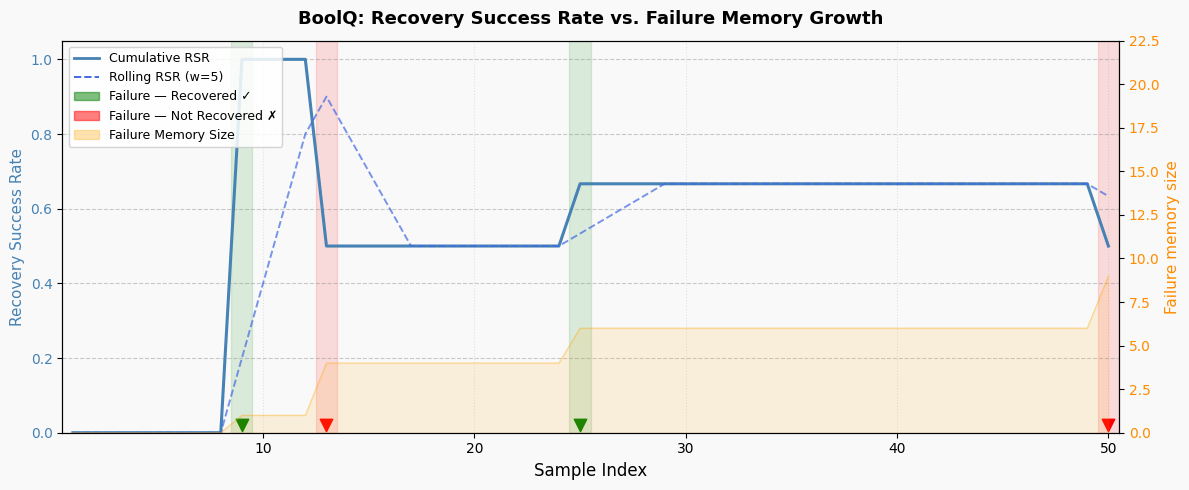

Plot saved to rsr_boolq.png


In [16]:
# ═══════════════════════════════════════════════════
# CELL 11 — Improved RSR Plot (BoolQ)
# ═══════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import csv

# ── Load data ───────────────────────────────────────
rsr_data  = list(csv.DictReader(open("rsr_boolq.csv")))
res_data  = list(csv.DictReader(open("boolq_results.csv")))

xs  = [int(r["sample"])      for r in rsr_data]
rsr = [float(r["rsr"])       for r in rsr_data]
mem = [int(r["memory_size"]) for r in rsr_data]

# ── Rolling RSR (window=5) ──────────────────────────
window = 5
rolling_rsr = []
for i in range(len(rsr)):
    start = max(0, i - window + 1)
    subset = rsr[start:i+1]
    rolling_rsr.append(sum(subset) / len(subset))

# ── Identify failure points ─────────────────────────
fail_xs        = []
recovery_color = []   # green=recovered, red=not recovered
for i, r in enumerate(res_data):
    if r["verif_flagged_invalid"] == "True":
        fail_xs.append(i + 1)
        recovery_color.append(
            "green" if r["recovery_succeeded"] == "True" else "red"
        )

# ── Plot ────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#f9f9f9")
ax1.set_facecolor("#f9f9f9")

# Grid
ax1.grid(axis="y", linestyle="--", alpha=0.4, color="gray")
ax1.grid(axis="x", linestyle=":", alpha=0.2, color="gray")

# Memory size fill (right axis)
ax2 = ax1.twinx()
ax2.fill_between(xs, mem, alpha=0.12, color="orange", label="Failure memory size")
ax2.plot(xs, mem, color="orange", linewidth=0.8, alpha=0.4)
ax2.set_ylabel("Failure memory size", color="darkorange", fontsize=11)
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.set_ylim(0, max(mem) * 2.5 if max(mem) > 0 else 5)

# Cumulative RSR line
ax1.plot(xs, rsr, color="steelblue", linewidth=2.2,
         label="Cumulative RSR", zorder=3)

# Rolling RSR line
ax1.plot(xs, rolling_rsr, color="royalblue", linewidth=1.4,
         linestyle="--", alpha=0.7, label=f"Rolling RSR (w={window})", zorder=3)

# Failure markers with recovery zones
for fx, fc in zip(fail_xs, recovery_color):
    # Shaded vertical zone
    ax1.axvspan(fx - 0.5, fx + 0.5, alpha=0.12,
                color=fc, zorder=1)
    # Dot on x-axis
    ax1.scatter(fx, 0.02, color=fc, s=80, zorder=5,
                marker="v", clip_on=False)

ax1.set_xlabel("Sample Index", fontsize=12)
ax1.set_ylabel("Recovery Success Rate", color="steelblue", fontsize=11)
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_ylim(0, 1.05)
ax1.set_xlim(min(xs) - 0.5, max(xs) + 0.5)

# Title
ax1.set_title("BoolQ: Recovery Success Rate vs. Failure Memory Growth",
              fontsize=13, fontweight="bold", pad=12)

# Legend
recovered_patch  = mpatches.Patch(color="green",     alpha=0.5, label="Failure — Recovered ✓")
failed_patch     = mpatches.Patch(color="red",        alpha=0.5, label="Failure — Not Recovered ✗")
memory_patch     = mpatches.Patch(color="orange",     alpha=0.3, label="Failure Memory Size")
cum_line         = plt.Line2D([0],[0], color="steelblue",  linewidth=2,   label="Cumulative RSR")
roll_line        = plt.Line2D([0],[0], color="royalblue",  linewidth=1.4,
                               linestyle="--", label=f"Rolling RSR (w={window})")
ax1.legend(handles=[cum_line, roll_line, recovered_patch, failed_patch, memory_patch],
           loc="upper left", fontsize=9, framealpha=0.85)

fig.tight_layout()
plt.savefig("rsr_boolq.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to rsr_boolq.png")